# Notebook 4 — Model Improvement & Tuning

Notebook 3 gave us a strong baseline with Gradient Boosting. This notebook asks a simple question:

> **Can we improve that baseline without using the test set to make our decisions?**

We will:
1. reproduce the Notebook 3 baseline;
2. tune Gradient Boosting with five-fold cross-validation;
3. test the log-to-dollar approach and the `Age²` idea from the earlier notebooks;
4. select the best candidate using training data only;
5. evaluate the selected model once on the untouched test set.

## The rule for this notebook

The test set stays closed until Section 12. All model decisions before that point use only the 23,880 training customers and cross-validation.


---

# 2. Setup and Configuration

## What are we doing?

Load the libraries, project paths, and configuration values used throughout the notebook.


In [1]:
import json
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

print("pandas       ", pd.__version__)
print("numpy        ", np.__version__)
print("scikit-learn ", sklearn.__version__)

pandas        2.2.3
numpy         2.1.3
scikit-learn  1.6.1


In [2]:
# --- Configuration -------------------------------------------------------
RANDOM_STATE = 42          # one seed for the whole notebook
CV_FOLDS = 5               # 5-fold cross-validation on the training data
N_SEARCH_ITER = 12         # candidate configurations drawn by the random search

TARGET_NAME = "Expected_Retirement_Fund"

# The metric that decides which candidate becomes the final model. Declared here,
# before any candidate has been evaluated.
SELECTION_METRIC = "RMSE ($)"

# The Notebook 3 baseline configuration. Section 5 checks this against the saved
# Notebook 3 model instead of trusting it.
BASELINE_PARAMS = {
    "n_estimators": 300,
    "learning_rate": 0.1,
    "max_depth": 3,
}

# Dollar predictions are floored before taking logs, because a model trained on
# the dollar target could in principle predict a non-positive amount.
DOLLAR_FLOOR = 1.0

print(f"RANDOM_STATE     {RANDOM_STATE}")
print(f"CV_FOLDS         {CV_FOLDS}")
print(f"N_SEARCH_ITER    {N_SEARCH_ITER}")
print(f"SELECTION_METRIC {SELECTION_METRIC} (cross-validated, training data only)")

RANDOM_STATE     42
CV_FOLDS         5
N_SEARCH_ITER    12
SELECTION_METRIC RMSE ($) (cross-validated, training data only)


In [3]:
# The repository root is the folder that contains src/, so the notebook runs
# from either the root or notebooks/. On Colab, clone the repository first.
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/Retirement-Readiness-Predictor"),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "src" / "feature_engineering.py").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root (the folder containing src/). Checked: "
        + ", ".join(str(path) for path in CANDIDATE_ROOTS)
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /home/claude/Retirement-Readiness-Predictor


In [4]:
# Same visual identity as Notebooks 1-3.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8E8",
    "font.size": 10,
})

NAVY = "#1F3B73"
TEAL = "#2A9D8F"
AMBER = "#E9A13B"
CORAL = "#E76F51"
SLATE = "#6C757D"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

---

# 3. Load Training Data and Artifacts

## What are we doing?

Load the training customers, the two target versions, and the preprocessing pipelines created in Notebook 2.

## Why?

Notebook 4 must build on the existing project rather than create a new preprocessing process.

The test data is deliberately not loaded here. It is opened only once in Section 12, after the model has been selected.


In [5]:
X_train_raw = pd.read_csv(ARTIFACTS_DIR / "X_train.csv.gz", index_col=0)

y_train_all = pd.read_csv(ARTIFACTS_DIR / "y_train.csv", index_col=0)
y_train_log = y_train_all.log_target            # what the models are trained on
y_train_dollars = y_train_all.target_dollars    # what the business cares about

# Fitted in Notebook 2 on the training data. Section 4 clones them so that every
# cross-validation fold refits its own copy.
preprocessor_unscaled = joblib.load(ARTIFACTS_DIR / "preprocessor_unscaled.joblib")
feature_names = pd.read_csv(ARTIFACTS_DIR / "feature_names.csv").feature.tolist()

TEST_FEATURES_PATH = ARTIFACTS_DIR / "X_test.csv.gz"    # opened in Section 12
TEST_TARGET_PATH = ARTIFACTS_DIR / "y_test.csv"         # opened in Section 12

print(f"Training records: {len(X_train_raw):,} rows x {X_train_raw.shape[1]} raw columns")
print(f"Features after preprocessing: {len(feature_names)}")
print(f"Target: {TARGET_NAME}  (log mean {y_train_log.mean():.4f})")
print(f"Training targets aligned with training rows: {X_train_raw.index.equals(y_train_log.index)}")
print()
print("Test set NOT loaded. Files stay closed until Section 12:")
print(f"   {TEST_FEATURES_PATH.name}   exists: {TEST_FEATURES_PATH.exists()}")
print(f"   {TEST_TARGET_PATH.name}       exists: {TEST_TARGET_PATH.exists()}")

Training records: 23,880 rows x 27 raw columns
Features after preprocessing: 40
Target: Expected_Retirement_Fund  (log mean 14.9062)
Training targets aligned with training rows: True

Test set NOT loaded. Files stay closed until Section 12:
   X_test.csv.gz   exists: True
   y_test.csv       exists: True


---

# 4. Evaluation Strategy

## What are we doing?

Set up five-fold cross-validation and the common scoring functions used by the experiments.

## How do we choose a model?

The main selection metric is **RMSE in dollars**.

Each fold is scored on its own held-out rows, and the five fold scores are averaged. This follows the convention used in Notebook 3.

The models are trained on `log(Expected_Retirement_Fund)`. The target is strongly right-skewed, so this keeps the training problem more manageable. For dollar-based evaluation, predictions are converted back with `np.exp()` before RMSE is calculated.

Log-space metrics are also reported, but dollar RMSE is the metric that decides the winner.

## How do we avoid leakage?

Every candidate starts with an unfitted clone of the Notebook 2 preprocessor. Each CV fold therefore learns its own medians, category levels, and scaling values from that fold's fitting rows only.


In [6]:
folds = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def gb_pipeline(model_params, add_age_squared=False):
    """Preprocessing (+ optional Age squared) + Gradient Boosting, as one estimator."""
    steps = [("preprocess", clone(preprocessor_unscaled))]

    if add_age_squared:
        # PolynomialFeatures on the single Age column returns [Age, Age^2]; every
        # other column passes through untouched. Nothing is learned from the data,
        # and the same step runs at training and at prediction time.
        steps.append(("age_squared", ColumnTransformer(
            transformers=[("age_poly",
                           PolynomialFeatures(degree=2, include_bias=False),
                           ["Age"])],
            remainder="passthrough",
            verbose_feature_names_out=False,
        ).set_output(transform="pandas")))

    steps.append(("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE, **model_params)))
    return Pipeline(steps)


def smearing_factor(actual_log, predicted_log):
    """Duan's smearing estimator: the mean of exp(residual)."""
    residuals = np.asarray(actual_log, dtype=float) - np.asarray(predicted_log, dtype=float)
    return float(np.mean(np.exp(residuals)))


def cross_validate_candidate(pipeline, log_target=True):
    """Fit the pipeline in each fold and predict only the rows it was not shown.

    Returns the dollar prediction for every training customer, the fold that held
    that customer out, and the smearing factor belonging to that fold.

    Each fold's factor is estimated from the residuals of its own fitting rows, so
    a validation row never contributes to the factor used to correct it.
    """
    target_values = y_train_log if log_target else y_train_dollars

    predicted_dollars = np.zeros(len(X_train_raw))
    fold_of_row = np.zeros(len(X_train_raw), dtype=int)
    factor_of_row = np.ones(len(X_train_raw))

    for fold_number, (fit_rows, validation_rows) in enumerate(folds.split(X_train_raw)):
        fitted = clone(pipeline).fit(
            X_train_raw.iloc[fit_rows], target_values.iloc[fit_rows]
        )
        fold_prediction = fitted.predict(X_train_raw.iloc[validation_rows])

        if log_target:
            factor_of_row[validation_rows] = smearing_factor(
                y_train_log.iloc[fit_rows], fitted.predict(X_train_raw.iloc[fit_rows]))
            fold_prediction = np.exp(fold_prediction)

        predicted_dollars[validation_rows] = fold_prediction
        fold_of_row[validation_rows] = fold_number

    return predicted_dollars, fold_of_row, factor_of_row

In [7]:
def score_predictions(name, actual_dollars, predicted_dollars):
    """The Notebook 3 metric set, computed from dollar predictions."""
    actual_dollars = np.asarray(actual_dollars, dtype=float)
    predicted_dollars = np.asarray(predicted_dollars, dtype=float)

    actual_log = np.log(actual_dollars)
    predicted_log = np.log(np.clip(predicted_dollars, DOLLAR_FLOOR, None))

    return {
        "Candidate": name,
        "R2 (log)": r2_score(actual_log, predicted_log),
        "RMSE (log)": np.sqrt(mean_squared_error(actual_log, predicted_log)),
        "MAE (log)": mean_absolute_error(actual_log, predicted_log),
        "R2 ($)": r2_score(actual_dollars, predicted_dollars),
        "RMSE ($)": np.sqrt(mean_squared_error(actual_dollars, predicted_dollars)),
        "MAE ($)": mean_absolute_error(actual_dollars, predicted_dollars),
        "MedianAE ($)": median_absolute_error(actual_dollars, predicted_dollars),
        "MAPE (%)": np.mean(np.abs((actual_dollars - predicted_dollars) / actual_dollars)) * 100,
        "Aggregate bias (%)": (predicted_dollars.mean() / actual_dollars.mean() - 1) * 100,
    }


# Columns holding dollar amounts, so display_table does not round R2 ($) to zero
# decimal places just because its name contains a currency symbol.
DOLLAR_AMOUNT_COLUMNS = ["RMSE ($)", "MAE ($)", "MedianAE ($)", "fold sd ($)"]


def display_table(table):
    """Round the metric columns so a printed table stays readable."""
    shown = table.copy()
    for column in shown.columns:
        if not pd.api.types.is_numeric_dtype(shown[column]):
            continue
        if column in DOLLAR_AMOUNT_COLUMNS:
            shown[column] = shown[column].round(0)
        elif column.endswith("(%)"):
            shown[column] = shown[column].round(2)
        else:
            shown[column] = shown[column].round(4)
    return shown


def cross_validated_scores(name, predicted_dollars, fold_of_row):
    """Score each fold on its own held-out rows, then average the five fold scores.

    Notebook 3 averaged its five fold RMSEs rather than pooling every held-out
    prediction into one calculation. Notebook 4 uses the same convention, so the
    baseline row here reproduces the Notebook 3 cross-validation figure.
    """
    predicted_dollars = np.asarray(predicted_dollars, dtype=float)
    fold_table = pd.DataFrame([
        score_predictions(name,
                          training_actual_dollars[fold_of_row == fold_number],
                          predicted_dollars[fold_of_row == fold_number])
        for fold_number in range(CV_FOLDS)
    ]).drop(columns="Candidate")

    averaged = fold_table.mean().to_dict()
    averaged["Candidate"] = name
    return averaged, fold_table["RMSE ($)"].to_numpy()


training_actual_dollars = y_train_dollars.to_numpy()
cv_scores = []          # one row per candidate, filled in by Sections 5-9
cv_stability = {}       # candidate -> per-fold dollar RMSE
print("Evaluation helpers ready.")

Evaluation helpers ready.


---

# 5. Reproduce the Notebook 3 Baseline

## What are we doing?

Before trying to improve anything, we recreate the existing baseline.

We:
1. check that the saved Notebook 3 model uses the expected hyperparameters;
2. refit the same model on the training data and compare its predictions with the saved model;
3. run five-fold cross-validation using the same scoring convention as Notebook 3.

## Why?

A baseline is useful only if we can reproduce it. It gives every experiment in this notebook a fixed point of comparison.


In [8]:
baseline_model_path = ARTIFACTS_DIR / "03_baseline_model.joblib"
baseline_results_path = ARTIFACTS_DIR / "03_baseline_model_results.csv"

notebook3_model = joblib.load(baseline_model_path)
notebook3_results = pd.read_csv(baseline_results_path, index_col=0)

notebook3_params = notebook3_model.named_steps["model"].get_params()
checked_params = {key: notebook3_params[key] for key in BASELINE_PARAMS}

print("Hyperparameters in the saved Notebook 3 model:")
for key, value in checked_params.items():
    print(f"   {key:<16} {value}   (expected {BASELINE_PARAMS[key]})")
print(f"   random_state     {notebook3_params['random_state']}   (expected {RANDOM_STATE})")

assert checked_params == BASELINE_PARAMS, "Notebook 3 used different hyperparameters."
assert notebook3_params["random_state"] == RANDOM_STATE, "Notebook 3 used a different seed."

print("\nNotebook 3 test-set row as recorded in 03_baseline_model_results.csv:")
print(notebook3_results[notebook3_results.Stage == "Test set"].round(4).to_string())

Hyperparameters in the saved Notebook 3 model:
   n_estimators     300   (expected 300)
   learning_rate    0.1   (expected 0.1)
   max_depth        3   (expected 3)
   random_state     42   (expected 42)

Notebook 3 test-set row as recorded in 03_baseline_model_results.csv:
                      Stage      R2  RMSE (log)  MAE (log)      RMSE ($)     MAE ($)  MAPE (%)  vs baseline
Model                                                                                                      
Gradient Boosting  Test set  0.8962      0.2814      0.203  1.265983e+06  769509.757   21.2819     -60.2022


In [9]:
# Refit the Notebook 3 specification from scratch and compare with the saved model
# on the training rows. The test set is not involved.
started = time.time()
reproduced_baseline = gb_pipeline(BASELINE_PARAMS).fit(X_train_raw, y_train_log)

saved_train_predictions = notebook3_model.predict(X_train_raw)
reproduced_train_predictions = reproduced_baseline.predict(X_train_raw)
largest_gap = np.max(np.abs(saved_train_predictions - reproduced_train_predictions))

print(f"Refitted in {time.time() - started:.0f}s")
print(f"Largest difference vs the saved Notebook 3 model (log space): {largest_gap:.3e}")

assert largest_gap < 1e-9, "The refitted baseline does not match the saved Notebook 3 model."
print("The Notebook 3 baseline is reproduced exactly.")

Refitted in 45s
Largest difference vs the saved Notebook 3 model (log space): 0.000e+00
The Notebook 3 baseline is reproduced exactly.


In [10]:
# The fixed benchmark: 5-fold cross-validated performance of the Notebook 3 model
# on the training data.
started = time.time()
baseline_oof_dollars, baseline_folds, _ = cross_validate_candidate(
    gb_pipeline(BASELINE_PARAMS))

baseline_results, baseline_fold_rmse = cross_validated_scores(
    "Baseline GB (Notebook 3)", baseline_oof_dollars, baseline_folds)
cv_scores.append(baseline_results)
cv_stability["Baseline GB (Notebook 3)"] = baseline_fold_rmse

print(f"Cross-validated in {time.time() - started:.0f}s\n")
print(pd.Series(baseline_results).drop("Candidate").round(4).to_string())
print(f"\nPer-fold dollar RMSE: {np.round(baseline_fold_rmse).astype(int)}")
print(f"Mean +/- sd: ${baseline_fold_rmse.mean():,.0f} +/- ${baseline_fold_rmse.std():,.0f}")

# Notebook 3 averaged its five fold RMSEs. Pooling every held-out prediction into
# a single RMSE is a different, slightly larger quantity; both are printed so the
# benchmark can be checked against the Notebook 3 figure rather than assumed.
pooled_rmse = np.sqrt(mean_squared_error(training_actual_dollars, baseline_oof_dollars))
print(f"\nMean of the five fold RMSEs (Notebook 3 convention): "
      f"${baseline_results['RMSE ($)']:,.0f}")
print(f"Pooled across all held-out rows at once:              ${pooled_rmse:,.0f}")
print(f"Difference between the two conventions:              "
      f"{(pooled_rmse / baseline_results['RMSE ($)'] - 1) * 100:+.3f}%")

Cross-validated in 178s

R2 (log)                    0.895256
RMSE (log)                  0.278717
MAE (log)                   0.200593
R2 ($)                      0.840288
RMSE ($)              1239045.186094
MAE ($)                760007.933182
MedianAE ($)           435762.004493
MAPE (%)                   20.765131
Aggregate bias (%)         -3.590696

Per-fold dollar RMSE: [1252778 1197435 1170120 1296835 1278058]
Mean +/- sd: $1,239,045 +/- $48,026

Mean of the five fold RMSEs (Notebook 3 convention): $1,239,045
Pooled across all held-out rows at once:              $1,239,976
Difference between the two conventions:              +0.075%


---

# 6. Tune Gradient Boosting

## What are we doing?

Search a compact set of Gradient Boosting hyperparameters using five-fold cross-validation on the training data.

The parameters tested are:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_samples_leaf`
- `subsample`

## Why a random search?

The full search space contains 72 combinations. We test 12 of them, which means 60 model fits across five folds instead of 360.

The random seed makes the selected combinations reproducible.

## What is being optimized?

The scorer converts each log-space prediction back to dollars with `np.exp()` and then calculates dollar RMSE.

So the search is aligned with the metric defined in Section 4.


In [11]:
def dollar_rmse_score(estimator, X_part, y_part_log):
    """Scorer for the search: dollar RMSE, negated because sklearn maximises."""
    predicted_dollars = np.exp(estimator.predict(X_part))
    actual_dollars = np.exp(y_part_log)
    return -np.sqrt(mean_squared_error(actual_dollars, predicted_dollars))


search_space = {
    "model__n_estimators": [300, 600],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__min_samples_leaf": [1, 5, 20],
    "model__subsample": [0.8, 1.0],
}

grid_size = int(np.prod([len(values) for values in search_space.values()]))
print(f"Full grid: {grid_size} combinations")
print(f"Sampled:   {N_SEARCH_ITER} combinations x {CV_FOLDS} folds "
      f"= {N_SEARCH_ITER * CV_FOLDS} model fits")

Full grid: 72 combinations
Sampled:   12 combinations x 5 folds = 60 model fits


In [12]:
# refit=False because the tuned model is re-evaluated in Section 7 with the same
# out-of-fold procedure used for every other candidate, and refitted once in
# Section 11. Only the training data is passed in.
search = RandomizedSearchCV(
    estimator=gb_pipeline(BASELINE_PARAMS),
    param_distributions=search_space,
    n_iter=N_SEARCH_ITER,
    scoring=dollar_rmse_score,
    cv=folds,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=False,
    verbose=1,
)

started = time.time()
search.fit(X_train_raw, y_train_log)
print(f"\nSearch finished in {(time.time() - started) / 60:.1f} minutes")

Fitting 5 folds for each of 12 candidates, totalling 60 fits



Search finished in 34.8 minutes


In [13]:
search_table = pd.DataFrame(search.cv_results_)
search_table["CV RMSE ($)"] = -search_table.mean_test_score
search_table["fold sd ($)"] = search_table.std_test_score

parameter_columns = [f"param_{name}" for name in search_space]
search_table = (search_table[parameter_columns + ["CV RMSE ($)", "fold sd ($)"]]
                .rename(columns=lambda name: name.replace("param_model__", ""))
                .sort_values("CV RMSE ($)")
                .reset_index(drop=True))

print(search_table.round({"CV RMSE ($)": 0, "fold sd ($)": 0}).to_string())

TUNED_PARAMS = {key.replace("model__", ""): value
                for key, value in search.best_params_.items()}
print("\nBest configuration found:")
for key, value in TUNED_PARAMS.items():
    print(f"   {key:<18} {value}")
print(f"\nSearch CV dollar RMSE: ${-search.best_score_:,.0f}")
print(f"Baseline CV dollar RMSE: ${baseline_results['RMSE ($)']:,.0f}")

    n_estimators  learning_rate  max_depth  min_samples_leaf  subsample  CV RMSE ($)  fold sd ($)
0            600           0.05          4                 5        0.8    1215716.0      40542.0
1            600           0.05          5                20        0.8    1215886.0      41004.0
2            600           0.10          3                20        1.0    1218769.0      44187.0
3            600           0.05          5                 5        1.0    1223197.0      44579.0
4            600           0.10          4                 5        0.8    1225675.0      42519.0
5            600           0.05          3                20        0.8    1230807.0      45298.0
6            600           0.10          4                 1        0.8    1231027.0      43949.0
7            300           0.05          5                 5        0.8    1231101.0      45025.0
8            600           0.10          5                 1        0.8    1235221.0      35694.0
9            300    

---

# 7. Evaluate the Tuned Model

## What are we doing?

Now we evaluate the selected Gradient Boosting configuration with the same out-of-fold procedure used for the baseline.

This gives us a full set of metrics for a fair comparison.

## Why do this separately?

The hyperparameter search is focused on dollar RMSE. Here we also calculate the other metrics used throughout the project, and we keep the out-of-fold log predictions for the next experiment.


In [14]:
started = time.time()
tuned_oof_dollars, tuned_folds, tuned_factors = cross_validate_candidate(
    gb_pipeline(TUNED_PARAMS))

tuned_results, tuned_fold_rmse = cross_validated_scores(
    "Tuned GB (log target)", tuned_oof_dollars, tuned_folds)
cv_scores.append(tuned_results)
cv_stability["Tuned GB (log target)"] = tuned_fold_rmse

print(f"Cross-validated in {time.time() - started:.0f}s\n")

baseline_vs_tuned = display_table(
    pd.DataFrame([baseline_results, tuned_results]).set_index("Candidate"))
print(baseline_vs_tuned.to_string())

change = (tuned_results["RMSE ($)"] / baseline_results["RMSE ($)"] - 1) * 100
print(f"\nTuned vs baseline on {SELECTION_METRIC}: {change:+.2f}%")
print(f"Baseline fold-to-fold sd: ${cv_stability['Baseline GB (Notebook 3)'].std():,.0f}")
print(f"Tuned fold-to-fold sd:    ${cv_stability['Tuned GB (log target)'].std():,.0f}")

Cross-validated in 375s

                          R2 (log)  RMSE (log)  MAE (log)  R2 ($)   RMSE ($)   MAE ($)  MedianAE ($)  MAPE (%)  Aggregate bias (%)
Candidate                                                                                                                         
Baseline GB (Notebook 3)    0.8953      0.2787     0.2006  0.8403  1239045.0  760008.0      435762.0     20.77               -3.59
Tuned GB (log target)       0.9000      0.2724     0.1951  0.8462  1215716.0  744377.0      427408.0     20.15               -3.26

Tuned vs baseline on RMSE ($): -1.88%
Baseline fold-to-fold sd: $48,026
Tuned fold-to-fold sd:    $40,542


---

# 8. Target-Scale Experiment

## What are we testing?

Notebook 3 found that simply applying `np.exp()` to a log-space prediction produced a portfolio total about 4% below the actual total.

We now compare three approaches using the tuned Gradient Boosting settings:

- **Log target + `exp()`** — the approach already evaluated in Section 7.
- **Log target + smearing** — multiply the dollar prediction by a correction estimated separately inside each CV fold.
- **Dollar target** — train Gradient Boosting directly on the dollar target.

All three are evaluated with cross-validation on the training data.

## Why test smearing?

A prediction in log space that is converted with `exp()` is median-centred under the usual log-normal interpretation. A smearing correction uses the residual distribution to move the prediction toward the conditional mean, which can help when dollar RMSE is the objective.

## Important limitation

For each fold, the smearing factor is estimated from that fold's fitting rows. The validation rows do not contribute to the factor used to score them.

The final model uses the same idea: after fitting on all training data, its smearing factor is estimated from the complete training set before the untouched test set is evaluated.


In [15]:
# Candidate A + smearing. Each held-out row is corrected by the factor its own
# fold produced, and that factor was estimated from the fold's fitting rows only.
smeared_oof_dollars = tuned_oof_dollars * tuned_factors

smeared_results, smeared_fold_rmse = cross_validated_scores(
    "Tuned GB (log + smearing)", smeared_oof_dollars, tuned_folds)
cv_scores.append(smeared_results)
cv_stability["Tuned GB (log + smearing)"] = smeared_fold_rmse

fold_factors = np.array([tuned_factors[tuned_folds == fold][0] for fold in range(CV_FOLDS)])
print(f"Per-fold smearing factors: {np.round(fold_factors, 5)}")
print(f"Mean factor: {fold_factors.mean():.5f}  "
      f"(each fold raises its own held-out predictions by "
      f"{(fold_factors.mean() - 1) * 100:.2f}% on average)")
print(f"Change in {SELECTION_METRIC} vs the uncorrected tuned model: "
      f"{(smeared_results['RMSE ($)'] / tuned_results['RMSE ($)'] - 1) * 100:+.2f}%")

Per-fold smearing factors: [1.02695 1.02713 1.02731 1.0267  1.0277 ]
Mean factor: 1.02716  (each fold raises its own held-out predictions by 2.72% on average)
Change in RMSE ($) vs the uncorrected tuned model: -0.83%


In [16]:
# Candidate B: the same pipeline trained directly on the dollar target.
started = time.time()
dollar_oof_dollars, dollar_folds, _ = cross_validate_candidate(
    gb_pipeline(TUNED_PARAMS), log_target=False)

non_positive = int((dollar_oof_dollars <= 0).sum())
print(f"Cross-validated in {time.time() - started:.0f}s")
print(f"Non-positive dollar predictions: {non_positive} "
      f"(floored at ${DOLLAR_FLOOR:,.0f} for the log-space metrics only)")

dollar_results, dollar_fold_rmse = cross_validated_scores(
    "Tuned GB (dollar target)", dollar_oof_dollars, dollar_folds)
cv_scores.append(dollar_results)
cv_stability["Tuned GB (dollar target)"] = dollar_fold_rmse

target_scale_table = display_table(
    pd.DataFrame([tuned_results, smeared_results, dollar_results]).set_index("Candidate"))
print()
print(target_scale_table.to_string())

Cross-validated in 385s
Non-positive dollar predictions: 9 (floored at $1 for the log-space metrics only)

                           R2 (log)  RMSE (log)  MAE (log)  R2 ($)   RMSE ($)   MAE ($)  MedianAE ($)  MAPE (%)  Aggregate bias (%)
Candidate                                                                                                                          
Tuned GB (log target)        0.9000      0.2724     0.1951  0.8462  1215716.0  744377.0      427408.0     20.15               -3.26
Tuned GB (log + smearing)    0.8990      0.2737     0.1959  0.8488  1205619.0  744689.0      430871.0     20.77               -0.64
Tuned GB (dollar target)     0.7936      0.3892     0.2188  0.8460  1216841.0  764244.0      460778.0     23.95               -0.03


Aggregate bias and prediction error measure different things.

A model should not be selected simply because its predictions add up to a portfolio total close to the actual total. The comparison therefore keeps the full error metrics visible, while the formal selection rule remains **lowest cross-validated dollar RMSE**.


---

# 9. Feature Experiment — `Age²`

## What are we testing?

Notebook 1 found that the relationship between `Age` and the target is curved rather than simply linear. It therefore suggested adding an `Age²` term.

Here we test that idea with the tuned Gradient Boosting model.

## What do we expect?

A tree model already creates threshold-based splits on `Age`. In this dataset, `Age²` is strictly increasing over the 22–69 age range, so it does not change the ordering of customers by age.

The experiment checks whether adding the transformed column provides any practical benefit anyway.

## Is it leakage-safe?

Yes. `Age²` is calculated from the customer's own `Age` value and uses no information from other records.

The feature is added through `PolynomialFeatures` inside this notebook. `src/feature_engineering.py` is not modified.


In [17]:
started = time.time()
age_pipeline = gb_pipeline(TUNED_PARAMS, add_age_squared=True)

# What the extra step does to the feature matrix.
age_preview = clone(age_pipeline[:-1]).fit_transform(X_train_raw)
print(f"Features without Age^2: {len(feature_names)}")
print(f"Features with Age^2:    {age_preview.shape[1]}   "
      f"(added: {[name for name in age_preview.columns if name not in feature_names]})")

age_oof_dollars, age_folds, _ = cross_validate_candidate(age_pipeline)

age_results, age_fold_rmse = cross_validated_scores(
    "Tuned GB + Age^2", age_oof_dollars, age_folds)
cv_scores.append(age_results)
cv_stability["Tuned GB + Age^2"] = age_fold_rmse

# Individual predictions shift a little, because adding a column changes the
# order in which the tree splitter considers features. That is a reshuffling
# effect, not new information.
prediction_gap = np.abs(age_oof_dollars - tuned_oof_dollars)
print(f"\nCross-validated in {time.time() - started:.0f}s")
print(f"Out-of-fold differences vs the tuned model ($): "
      f"median {np.median(prediction_gap):,.0f}, max {prediction_gap.max():,.0f}")
print(f"Correlation between the two sets of predictions: "
      f"{np.corrcoef(age_oof_dollars, tuned_oof_dollars)[0, 1]:.6f}")
print(f"Change in {SELECTION_METRIC}: "
      f"{(age_results['RMSE ($)'] / tuned_results['RMSE ($)'] - 1) * 100:+.4f}%   "
      f"(fold-to-fold sd is ${cv_stability['Tuned GB (log target)'].std():,.0f})")

Features without Age^2: 40
Features with Age^2:    41   (added: ['Age^2'])



Cross-validated in 381s
Out-of-fold differences vs the tuned model ($): median 27,185, max 1,653,121
Correlation between the two sets of predictions: 0.999493
Change in RMSE ($): +0.0871%   (fold-to-fold sd is $40,542)


## `Retirement_Fund_Goal` — carried forward, not repeated

Notebook 3 already tested the effect of removing `Retirement_Fund_Goal` and found only about a 0.5% change in dollar RMSE.

There is no reason to repeat the same experiment here. None of the experiments in Sections 6–9 changes that feature decision, so the Notebook 3 finding is carried forward.


---

# 10. Compare Candidates and Select the Final Model

## What are we doing?

Bring the candidate models into one comparison table.

## Selection rule

**The candidate with the lowest cross-validated dollar RMSE wins.**

The decision uses training data only. The test set has not been opened, and there is no manual selection based on the final test result.


In [18]:
cv_comparison = pd.DataFrame(cv_scores).set_index("Candidate")
cv_comparison["fold sd ($)"] = [cv_stability[name].std() for name in cv_comparison.index]
cv_comparison = cv_comparison.sort_values(SELECTION_METRIC)

print(display_table(cv_comparison).to_string())

                           R2 (log)  RMSE (log)  MAE (log)  R2 ($)   RMSE ($)   MAE ($)  MedianAE ($)  MAPE (%)  Aggregate bias (%)  fold sd ($)
Candidate                                                                                                                                       
Tuned GB (log + smearing)    0.8990      0.2737     0.1959  0.8488  1205619.0  744689.0      430871.0     20.77               -0.64      40950.0
Tuned GB (log target)        0.9000      0.2724     0.1951  0.8462  1215716.0  744377.0      427408.0     20.15               -3.26      40542.0
Tuned GB + Age^2             0.8997      0.2728     0.1953  0.8460  1216776.0  744761.0      427552.0     20.16               -3.30      42587.0
Tuned GB (dollar target)     0.7936      0.3892     0.2188  0.8460  1216841.0  764244.0      460778.0     23.95               -0.03      34562.0
Baseline GB (Notebook 3)     0.8953      0.2787     0.2006  0.8403  1239045.0  760008.0      435762.0     20.77               -3.5

In [19]:
# The selection rule, applied in code rather than by reading the table.
FINAL_CANDIDATE = cv_comparison[SELECTION_METRIC].idxmin()

print(f"Selection metric: {SELECTION_METRIC} (5-fold CV, training data only)")
print(f"Selected candidate: {FINAL_CANDIDATE}")
print(f"   CV {SELECTION_METRIC}: ${cv_comparison.loc[FINAL_CANDIDATE, SELECTION_METRIC]:,.0f}")
print(f"   vs Notebook 3 baseline: "
      f"{(cv_comparison.loc[FINAL_CANDIDATE, SELECTION_METRIC] / baseline_results['RMSE ($)'] - 1) * 100:+.2f}%")
print(f"\nPer-fold dollar RMSE of the winner: "
      f"{np.round(cv_stability[FINAL_CANDIDATE]).astype(int)}")

# How each candidate is turned into dollars, so Section 11 can rebuild the winner.
CANDIDATE_RECIPES = {
    "Baseline GB (Notebook 3)":   {"params": BASELINE_PARAMS, "target_scale": "log",
                                   "smearing": False, "age_squared": False},
    "Tuned GB (log target)":      {"params": TUNED_PARAMS, "target_scale": "log",
                                   "smearing": False, "age_squared": False},
    "Tuned GB (log + smearing)":  {"params": TUNED_PARAMS, "target_scale": "log",
                                   "smearing": True, "age_squared": False},
    "Tuned GB (dollar target)":   {"params": TUNED_PARAMS, "target_scale": "dollars",
                                   "smearing": False, "age_squared": False},
    "Tuned GB + Age^2":           {"params": TUNED_PARAMS, "target_scale": "log",
                                   "smearing": False, "age_squared": True},
}

# Copied, because Section 11 fills in the smearing factor once the final model exists.
final_config = dict(CANDIDATE_RECIPES[FINAL_CANDIDATE])
print("\nFinal configuration:")
print(json.dumps(final_config, indent=3, default=str))

Selection metric: RMSE ($) (5-fold CV, training data only)
Selected candidate: Tuned GB (log + smearing)
   CV RMSE ($): $1,205,619
   vs Notebook 3 baseline: -2.70%

Per-fold dollar RMSE of the winner: [1213709 1162853 1154410 1258043 1239080]

Final configuration:
{
   "params": {
      "subsample": 0.8,
      "n_estimators": 600,
      "min_samples_leaf": 5,
      "max_depth": 4,
      "learning_rate": 0.05
   },
   "target_scale": "log",
   "smearing": true,
   "age_squared": false
}


---

# 11. Fit the Final Model on All Training Data

## What are we doing?

The candidate has now been selected using cross-validation.

We fit that final specification on all **23,880 training customers** so it can use all available training information.

The test set is still closed.


In [20]:
def predict_dollars(model, X_raw, config):
    """Turn a fitted pipeline's output into dollars, following the saved recipe."""
    predictions = model.predict(X_raw)
    if config["target_scale"] == "log":
        predictions = np.exp(predictions) * config["smearing_factor"]
    return predictions


started = time.time()
final_model = gb_pipeline(final_config["params"], add_age_squared=final_config["age_squared"])
final_target = y_train_log if final_config["target_scale"] == "log" else y_train_dollars
final_model.fit(X_train_raw, final_target)

# The final model estimates its smearing factor the same way each fold did: from
# its own residuals on the rows it was fitted on, which are all of the training
# data here. The test set plays no part in it.
if final_config["smearing"]:
    final_config["smearing_factor"] = smearing_factor(
        y_train_log, final_model.predict(X_train_raw))
else:
    final_config["smearing_factor"] = 1.0

n_final_features = final_model[:-1].transform(X_train_raw.head(5)).shape[1]

print(f"Fitted '{FINAL_CANDIDATE}' on {len(X_train_raw):,} training rows "
      f"in {time.time() - started:.0f}s")
print(f"Trained on: {'log target' if final_config['target_scale'] == 'log' else 'dollar target'}")
print(f"Features entering the model: {n_final_features}")
print(f"Smearing factor applied at prediction time: {final_config['smearing_factor']:.5f}")

Fitted 'Tuned GB (log + smearing)' on 23,880 training rows in 95s
Trained on: log target
Features entering the model: 40
Smearing factor applied at prediction time: 1.02893


---

# 12. Final Test Evaluation

## What are we doing?

The model has been selected and fitted, so we can finally open the test set.

The final model and the Notebook 3 baseline are both evaluated on the same **5,970 customers that were not used during model selection**.

## Why evaluate the baseline again?

This gives us a direct, like-for-like comparison between Notebook 3 and Notebook 4 using calculations performed in the same notebook.

The recomputed baseline is also checked against the saved Notebook 3 results.


In [21]:
# ===================== THE TEST SET IS OPENED HERE =======================
X_test_raw = pd.read_csv(TEST_FEATURES_PATH, index_col=0)
y_test_all = pd.read_csv(TEST_TARGET_PATH, index_col=0)
y_test_log = y_test_all.log_target
y_test_dollars = y_test_all.target_dollars
# =========================================================================

print(f"Test records: {len(X_test_raw):,} rows x {X_test_raw.shape[1]} raw columns")
print(f"Rows shared with the training set: "
      f"{len(X_test_raw.index.intersection(X_train_raw.index))}")
print(f"Raw columns identical to training: "
      f"{list(X_test_raw.columns) == list(X_train_raw.columns)}")

Test records: 5,970 rows x 27 raw columns
Rows shared with the training set: 0
Raw columns identical to training: True


In [22]:
baseline_test_dollars = np.exp(notebook3_model.predict(X_test_raw))
final_test_dollars = predict_dollars(final_model, X_test_raw, final_config)

test_actual_dollars = y_test_dollars.to_numpy()
baseline_test_scores = score_predictions("Baseline GB (Notebook 3)",
                                         test_actual_dollars, baseline_test_dollars)
final_test_scores = score_predictions(f"Final: {FINAL_CANDIDATE}",
                                      test_actual_dollars, final_test_dollars)

test_comparison = display_table(
    pd.DataFrame([baseline_test_scores, final_test_scores]).set_index("Candidate"))
print(test_comparison.to_string())

                                  R2 (log)  RMSE (log)  MAE (log)  R2 ($)   RMSE ($)   MAE ($)  MedianAE ($)  MAPE (%)  Aggregate bias (%)
Candidate                                                                                                                                 
Baseline GB (Notebook 3)            0.8962      0.2814     0.2030  0.8429  1265983.0  769510.0      448701.0     21.28               -4.11
Final: Tuned GB (log + smearing)    0.9022      0.2731     0.1972  0.8515  1231163.0  753165.0      436662.0     21.01               -1.05


In [23]:
# Does the baseline recomputed here match what Notebook 3 recorded?
recorded = notebook3_results[notebook3_results.Stage == "Test set"].iloc[0]
recorded_pairs = [
    ("R2 (log)", "R2"),
    ("RMSE (log)", "RMSE (log)"),
    ("MAE (log)", "MAE (log)"),
    ("RMSE ($)", "RMSE ($)"),
    ("MAE ($)", "MAE ($)"),
    ("MAPE (%)", "MAPE (%)"),
]

recheck = pd.DataFrame([
    {"metric": here,
     "Notebook 3 file": recorded[there],
     "recomputed here": baseline_test_scores[here],
     "difference (%)": (baseline_test_scores[here] / recorded[there] - 1) * 100}
    for here, there in recorded_pairs
]).set_index("metric")

print(recheck.round(6).to_string())
largest_drift = recheck["difference (%)"].abs().max()
print(f"\nLargest disagreement with the Notebook 3 results file: {largest_drift:.4f}%")
assert largest_drift < 1.0, "The recomputed baseline disagrees with Notebook 3 by more than 1%."

            Notebook 3 file  recomputed here  difference (%)
metric                                                      
R2 (log)       8.961810e-01     8.961810e-01        0.000030
RMSE (log)     2.813890e-01     2.813890e-01       -0.000047
MAE (log)      2.030020e-01     2.030020e-01        0.000233
RMSE ($)       1.265983e+06     1.265983e+06       -0.000000
MAE ($)        7.695098e+05     7.695098e+05       -0.000000
MAPE (%)       2.128186e+01     2.128186e+01       -0.000001

Largest disagreement with the Notebook 3 results file: 0.0002%


In [24]:
# Improvements, calculated rather than typed.
improvement_rows = []
for metric in ["RMSE ($)", "MAE ($)", "MedianAE ($)", "MAPE (%)",
               "RMSE (log)", "MAE (log)"]:
    before, after = baseline_test_scores[metric], final_test_scores[metric]
    improvement_rows.append({
        "metric": metric,
        "baseline": before,
        "final": after,
        "change (%)": (after / before - 1) * 100,
    })
for metric in ["R2 (log)", "R2 ($)"]:
    before, after = baseline_test_scores[metric], final_test_scores[metric]
    improvement_rows.append({
        "metric": metric, "baseline": before, "final": after,
        "change (%)": np.nan,
    })

improvements = pd.DataFrame(improvement_rows).set_index("metric")
improvements["absolute change"] = improvements["final"] - improvements["baseline"]

print(improvements.to_string(float_format=lambda value: f"{value:,.4f}"))
print(f"\nRMSE improvement: {-improvements.loc['RMSE ($)', 'change (%)']:.2f}%")
print(f"MAE improvement:  {-improvements.loc['MAE ($)', 'change (%)']:.2f}%")
print(f"R2 (log) change:  {improvements.loc['R2 (log)', 'absolute change']:+.4f}")
print(f"Aggregate bias:   {baseline_test_scores['Aggregate bias (%)']:+.2f}% "
      f"-> {final_test_scores['Aggregate bias (%)']:+.2f}%")

                   baseline          final  change (%)  absolute change
metric                                                                 
RMSE ($)     1,265,982.7072 1,231,162.9358     -2.7504     -34,819.7714
MAE ($)        769,509.7570   753,165.4836     -2.1240     -16,344.2734
MedianAE ($)   448,701.0896   436,661.8044     -2.6831     -12,039.2852
MAPE (%)            21.2819        21.0147     -1.2555          -0.2672
RMSE (log)           0.2814         0.2731     -2.9571          -0.0083
MAE (log)            0.2030         0.1972     -2.8659          -0.0058
R2 (log)             0.8962         0.9022         NaN           0.0060
R2 ($)               0.8429         0.8515         NaN           0.0085

RMSE improvement: 2.75%
MAE improvement:  2.12%
R2 (log) change:  +0.0060
Aggregate bias:   -4.11% -> -1.05%


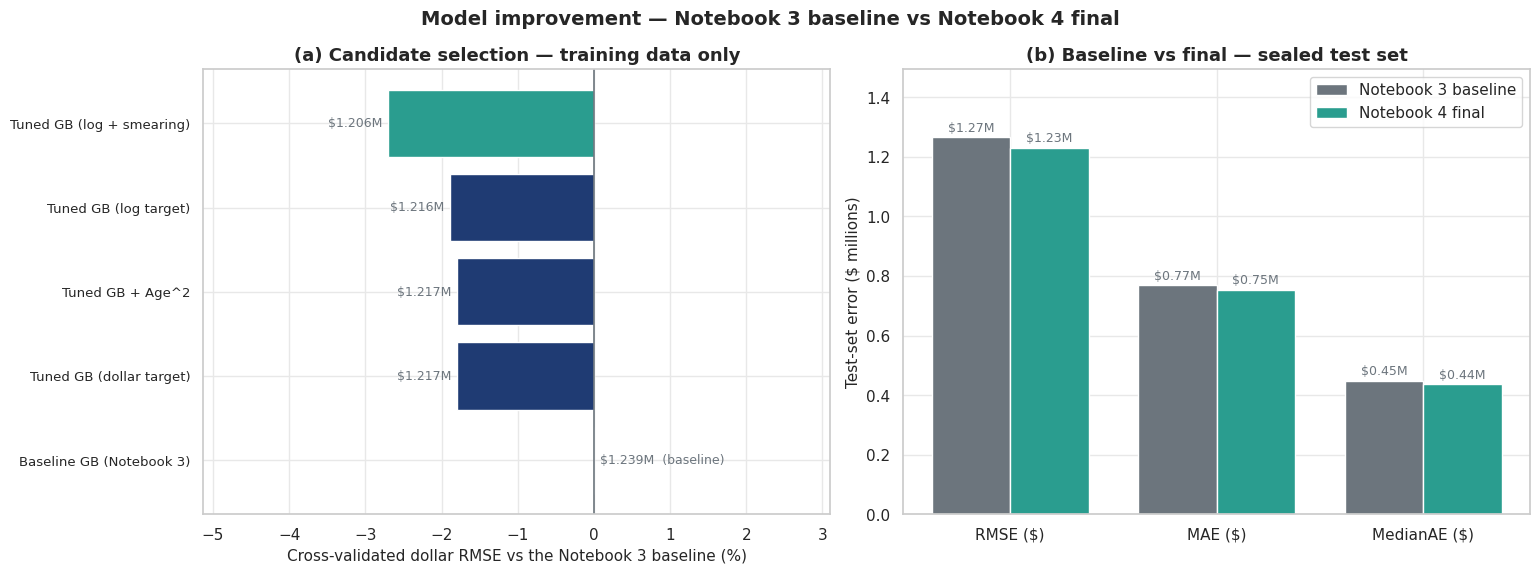

In [25]:
# --- FIGURE 1: selection evidence and the final test comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

# Every candidate lands within a few percent of the baseline, so the bars show
# the change relative to it. The absolute figure is printed beside each bar.
baseline_cv_rmse = cv_comparison.loc["Baseline GB (Notebook 3)", SELECTION_METRIC]
ordered = cv_comparison.sort_values(SELECTION_METRIC, ascending=False)
change_vs_baseline = (ordered[SELECTION_METRIC] / baseline_cv_rmse - 1) * 100
positions = np.arange(len(ordered))
colours = [TEAL if name == FINAL_CANDIDATE else NAVY for name in ordered.index]

axes[0].barh(positions, change_vs_baseline, color=colours, edgecolor="white")
axes[0].axvline(0, color=SLATE, lw=1.2)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(ordered.index, fontsize=9.5)
axes[0].set_xlabel("Cross-validated dollar RMSE vs the Notebook 3 baseline (%)")
axes[0].set_title("(a) Candidate selection — training data only")

for position, name, percent, absolute in zip(positions, ordered.index,
                                             change_vs_baseline,
                                             ordered[SELECTION_METRIC]):
    label = f"${absolute / 1e6:.3f}M"
    if name == "Baseline GB (Notebook 3)":
        label += "  (baseline)"
    if percent < 0:
        axes[0].text(percent - 0.08, position, label, va="center", ha="right",
                     fontsize=9, color=SLATE)
    else:
        axes[0].text(percent + 0.08, position, label, va="center", ha="left",
                     fontsize=9, color=SLATE)

span = max(abs(change_vs_baseline.min()), abs(change_vs_baseline.max()), 1.0)
axes[0].set_xlim(-span * 1.9, span * 1.15)

metrics = ["RMSE ($)", "MAE ($)", "MedianAE ($)"]
baseline_values = [baseline_test_scores[metric] / 1e6 for metric in metrics]
final_values = [final_test_scores[metric] / 1e6 for metric in metrics]
offsets = np.arange(len(metrics))

axes[1].bar(offsets - 0.19, baseline_values, width=0.38, color=SLATE,
            edgecolor="white", label="Notebook 3 baseline")
axes[1].bar(offsets + 0.19, final_values, width=0.38, color=TEAL,
            edgecolor="white", label="Notebook 4 final")
axes[1].set_xticks(offsets)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel("Test-set error ($ millions)")
axes[1].set_title("(b) Baseline vs final — sealed test set")
for offset, before, after in zip(offsets, baseline_values, final_values):
    axes[1].text(offset - 0.19, before + 0.02, f"${before:.2f}M", ha="center", fontsize=9,
                 color=SLATE)
    axes[1].text(offset + 0.19, after + 0.02, f"${after:.2f}M", ha="center", fontsize=9,
                 color=SLATE)
axes[1].set_ylim(0, max(baseline_values + final_values) * 1.18)
axes[1].legend(frameon=True)

fig.suptitle("Model improvement — Notebook 3 baseline vs Notebook 4 final",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_model_comparison.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---

# 13. Prediction and Residual Diagnostics

## What are we checking?

We use the same two diagnostic views from Notebook 3 for the final model:

- predicted values compared with actual values;
- residuals compared with predicted values.

These plots help us see patterns that a single summary metric cannot show.


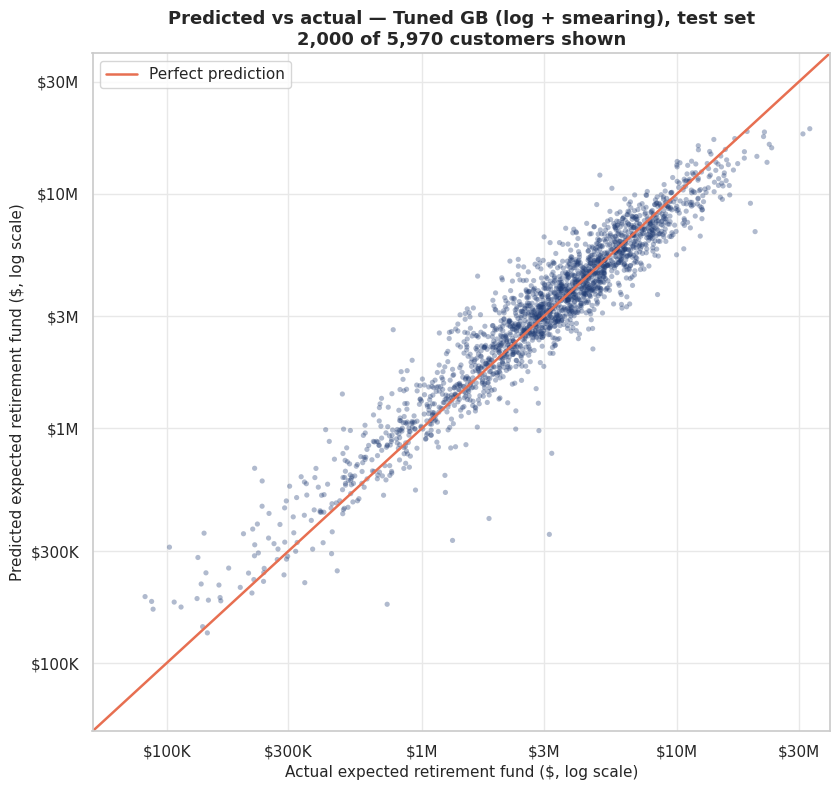

In [26]:
# --- FIGURE 2: predicted vs actual, final model --------------------------
sample = pd.DataFrame({
    "actual": test_actual_dollars,
    "predicted": final_test_dollars,
}).sample(2000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 8))
ax.scatter(sample.actual, sample.predicted, s=14, alpha=0.35, color=NAVY, edgecolors="none")

limits = [test_actual_dollars.min() * 0.8, test_actual_dollars.max() * 1.2]
ax.plot(limits, limits, color=CORAL, lw=1.8, label="Perfect prediction")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Actual expected retirement fund ($, log scale)")
ax.set_ylabel("Predicted expected retirement fund ($, log scale)")
ax.set_title(f"Predicted vs actual — {FINAL_CANDIDATE}, test set\n"
             f"2,000 of {len(y_test_dollars):,} customers shown")

tick_values = [1e5, 3e5, 1e6, 3e6, 1e7, 3e7]
tick_labels = ["$100K", "$300K", "$1M", "$3M", "$10M", "$30M"]
ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_values)
ax.set_yticklabels(tick_labels)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_predicted_vs_actual.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

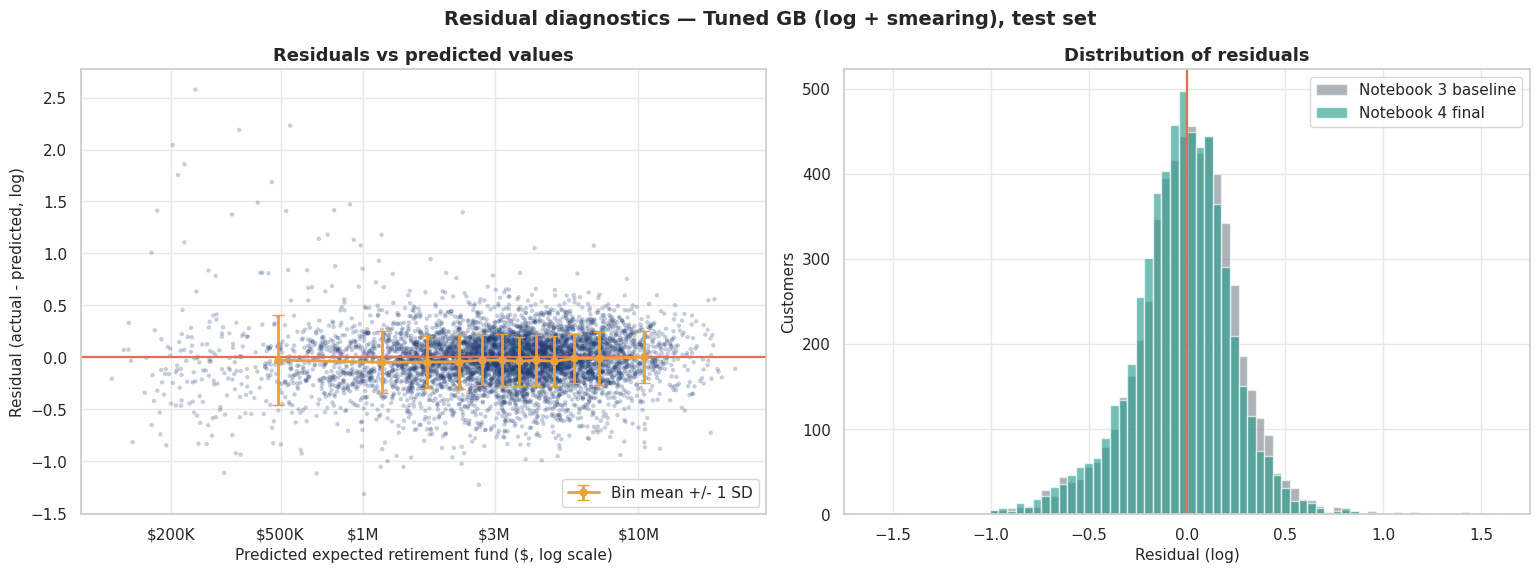

In [27]:
# --- FIGURE 3: residual diagnostics, final model -------------------------
final_test_log = np.log(np.clip(final_test_dollars, DOLLAR_FLOOR, None))
baseline_test_log = np.log(np.clip(baseline_test_dollars, DOLLAR_FLOOR, None))
final_residuals = y_test_log.to_numpy() - final_test_log
baseline_residuals = y_test_log.to_numpy() - baseline_test_log

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

axes[0].scatter(final_test_log, final_residuals, s=10, alpha=0.25, color=NAVY,
                edgecolors="none")
axes[0].axhline(0, color=CORAL, lw=1.6)

bins = pd.qcut(final_test_log, 12, labels=False)
binned = pd.DataFrame({"prediction": final_test_log,
                       "residual": final_residuals,
                       "bin": bins}).groupby("bin").agg(
    centre=("prediction", "mean"),
    mean_residual=("residual", "mean"),
    spread=("residual", "std"),
)
axes[0].errorbar(binned.centre, binned.mean_residual, yerr=binned.spread,
                 color=AMBER, lw=2, marker="o", markersize=5, capsize=4,
                 label="Bin mean +/- 1 SD")
axes[0].set_xticks(np.log([2e5, 5e5, 1e6, 3e6, 1e7]))
axes[0].set_xticklabels(["$200K", "$500K", "$1M", "$3M", "$10M"])
axes[0].set_xlabel("Predicted expected retirement fund ($, log scale)")
axes[0].set_ylabel("Residual (actual - predicted, log)")
axes[0].set_title("Residuals vs predicted values")
axes[0].legend(loc="lower right", frameon=True)

axes[1].hist(baseline_residuals, bins=80, range=(-1.75, 1.75), color=SLATE,
             alpha=0.55, edgecolor="white", label="Notebook 3 baseline")
axes[1].hist(final_residuals, bins=80, range=(-1.75, 1.75), color=TEAL,
             alpha=0.65, edgecolor="white", label="Notebook 4 final")
axes[1].axvline(0, color=CORAL, lw=1.6)
axes[1].set_xlim(-1.75, 1.75)
axes[1].set_xlabel("Residual (log)")
axes[1].set_ylabel("Customers")
axes[1].set_title("Distribution of residuals")
axes[1].legend(frameon=True)

fig.suptitle(f"Residual diagnostics — {FINAL_CANDIDATE}, test set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_residuals.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

In [28]:
# The two patterns Notebook 3 measured, recomputed for both models.
quintile_labels = ["1 (lowest)", "2", "3", "4", "5 (highest)"]
baseline_quintile = pd.qcut(baseline_test_log, 5, labels=quintile_labels)
final_quintile = pd.qcut(final_test_log, 5, labels=quintile_labels)

residual_spread = pd.DataFrame({
    "baseline mean": pd.Series(baseline_residuals).groupby(baseline_quintile, observed=True).mean(),
    "baseline sd": pd.Series(baseline_residuals).groupby(baseline_quintile, observed=True).std(),
    "final mean": pd.Series(final_residuals).groupby(final_quintile, observed=True).mean(),
    "final sd": pd.Series(final_residuals).groupby(final_quintile, observed=True).std(),
})
print("Residuals by predicted quintile (log space):")
print(residual_spread.round(4).to_string())

print(f"\nMean actual            ${test_actual_dollars.mean():>14,.0f}")
print(f"Mean predicted baseline ${baseline_test_dollars.mean():>14,.0f}  "
      f"({baseline_test_scores['Aggregate bias (%)']:+.2f}%)")
print(f"Mean predicted final    ${final_test_dollars.mean():>14,.0f}  "
      f"({final_test_scores['Aggregate bias (%)']:+.2f}%)")

Residuals by predicted quintile (log space):
             baseline mean  baseline sd  final mean  final sd
1 (lowest)         -0.0141       0.3745     -0.0388    0.3554
2                  -0.0167       0.2679     -0.0386    0.2536
3                   0.0061       0.2460     -0.0326    0.2413
4                   0.0013       0.2478     -0.0233    0.2403
5 (highest)         0.0209       0.2477     -0.0087    0.2488

Mean actual            $     4,062,102
Mean predicted baseline $     3,894,958  (-4.11%)
Mean predicted final    $     4,019,345  (-1.05%)


---

# 14. Error Analysis by Segment

## What are we checking?

Notebook 3 identified three areas where errors deserved attention:

- lower-value customers;
- the lowest income group;
- customers more than 30 years from retirement.

We use the same definitions here to see whether the final model improved those areas.

## Segment definitions

The income groups use the training-data salary quintiles, and the retirement-horizon groups use the four bands defined in Notebook 1.

Keeping the definitions unchanged makes the comparison with Notebook 3 fair.


In [29]:
# Segment columns come from the Notebook 2 preprocessing output, exactly as in
# Notebook 3. This is for reporting only; no model is fitted on them.
X_train_tree = preprocessor_unscaled.transform(X_train_raw)
X_test_tree = preprocessor_unscaled.transform(X_test_raw)

errors = pd.DataFrame({
    "actual": test_actual_dollars,
    "baseline_error": np.abs(baseline_test_dollars - test_actual_dollars),
    "final_error": np.abs(final_test_dollars - test_actual_dollars),
    "salary": X_test_tree.AnnualSalary.to_numpy(),
    "years_until_retirement": X_test_tree.YearsUntilRetirement.to_numpy(),
})
errors["baseline_pct"] = errors.baseline_error / errors.actual * 100
errors["final_pct"] = errors.final_error / errors.actual * 100

salary_cuts = ([-np.inf]
               + list(X_train_tree.AnnualSalary.quantile([0.2, 0.4, 0.6, 0.8]))
               + [np.inf])
errors["IncomeQuintile"] = pd.cut(
    errors.salary, bins=salary_cuts,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])
errors["HorizonBand"] = pd.cut(
    errors.years_until_retirement, bins=[0, 10, 20, 30, 50],
    labels=["1-10 yrs", "11-20 yrs", "21-30 yrs", "31+ yrs"])


def compare_segment(group_column):
    """Baseline vs final error within one segmentation."""
    grouped = errors.groupby(group_column, observed=True)
    summary = grouped.agg(
        customers=("actual", "size"),
        baseline_MAE=("baseline_error", "mean"),
        final_MAE=("final_error", "mean"),
        baseline_MAPE=("baseline_pct", "mean"),
        final_MAPE=("final_pct", "mean"),
    )
    summary["MAE change (%)"] = (summary.final_MAE / summary.baseline_MAE - 1) * 100
    summary["MAPE change (pp)"] = summary.final_MAPE - summary.baseline_MAPE
    return summary


income_comparison = compare_segment("IncomeQuintile")
horizon_comparison = compare_segment("HorizonBand")

print("By income quintile")
print(income_comparison.round(2).to_string())
print("\nBy retirement horizon")
print(horizon_comparison.round(2).to_string())

By income quintile
                customers  baseline_MAE   final_MAE  baseline_MAPE  final_MAPE  MAE change (%)  MAPE change (pp)
IncomeQuintile                                                                                                  
Q1 (lowest)          1189     301515.08   287907.95          27.61       25.73           -4.51             -1.88
Q2                   1212     520781.65   517557.05          20.56       20.94           -0.62              0.38
Q3                   1188     729977.10   709491.47          20.59       20.46           -2.81             -0.13
Q4                   1203     865331.14   842625.61          18.39       18.50           -2.62              0.10
Q5 (highest)         1178    1439794.84  1417862.28          19.28       19.46           -1.52              0.18

By retirement horizon
             customers  baseline_MAE  final_MAE  baseline_MAPE  final_MAPE  MAE change (%)  MAPE change (pp)
HorizonBand                                               

In [30]:
print("Absolute error percentiles ($):")
print(f"   {'percentile':<12}{'baseline':>14}{'final':>14}{'change':>10}")
for percentile in [50, 75, 90, 95, 99]:
    before = np.percentile(errors.baseline_error, percentile)
    after = np.percentile(errors.final_error, percentile)
    print(f"   p{percentile:<11}{before:>14,.0f}{after:>14,.0f}"
          f"{(after / before - 1) * 100:>9.1f}%")

print(f"\nWithin 10% of the actual amount: "
      f"{(errors.baseline_pct <= 10).mean() * 100:.1f}% -> {(errors.final_pct <= 10).mean() * 100:.1f}%")
print(f"Within 25% of the actual amount: "
      f"{(errors.baseline_pct <= 25).mean() * 100:.1f}% -> {(errors.final_pct <= 25).mean() * 100:.1f}%")
print(f"Median absolute percentage error: "
      f"{errors.baseline_pct.median():.1f}% -> {errors.final_pct.median():.1f}%")
print(f"Customers with a smaller absolute error under the final model: "
      f"{(errors.final_error < errors.baseline_error).mean() * 100:.1f}%")

Absolute error percentiles ($):
   percentile        baseline         final    change
   p50                448,701       436,662     -2.7%
   p75                961,708       961,580     -0.0%
   p90              1,853,898     1,789,088     -3.5%
   p95              2,668,285     2,565,985     -3.8%
   p99              4,702,836     4,498,751     -4.3%

Within 10% of the actual amount: 33.6% -> 35.3%
Within 25% of the actual amount: 72.5% -> 72.7%
Median absolute percentage error: 15.3% -> 14.9%
Customers with a smaller absolute error under the final model: 52.7%


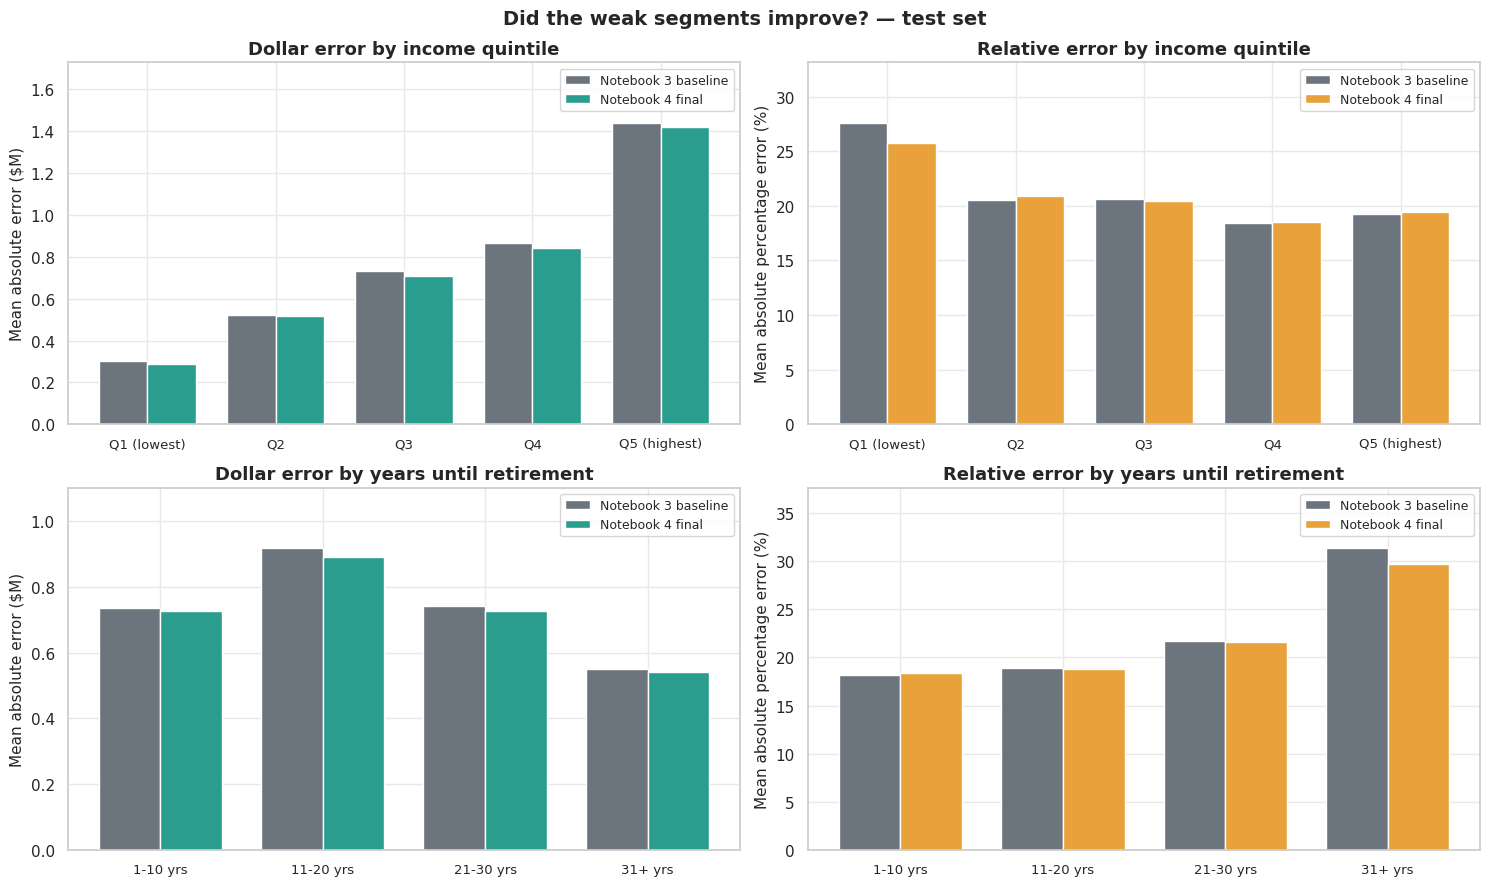

In [31]:
# --- FIGURE 4: baseline vs final error by segment ------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for row, (summary, label) in enumerate([(income_comparison, "income quintile"),
                                        (horizon_comparison, "years until retirement")]):
    offsets = np.arange(len(summary))

    axes[row, 0].bar(offsets - 0.19, summary.baseline_MAE / 1e6, width=0.38,
                     color=SLATE, edgecolor="white", label="Notebook 3 baseline")
    axes[row, 0].bar(offsets + 0.19, summary.final_MAE / 1e6, width=0.38,
                     color=TEAL, edgecolor="white", label="Notebook 4 final")
    axes[row, 0].set_xticks(offsets)
    axes[row, 0].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 0].set_ylabel("Mean absolute error ($M)")
    axes[row, 0].set_title(f"Dollar error by {label}")
    axes[row, 0].set_ylim(0, summary[["baseline_MAE", "final_MAE"]].to_numpy().max() / 1e6 * 1.2)
    axes[row, 0].legend(fontsize=9, frameon=True)

    axes[row, 1].bar(offsets - 0.19, summary.baseline_MAPE, width=0.38,
                     color=SLATE, edgecolor="white", label="Notebook 3 baseline")
    axes[row, 1].bar(offsets + 0.19, summary.final_MAPE, width=0.38,
                     color=AMBER, edgecolor="white", label="Notebook 4 final")
    axes[row, 1].set_xticks(offsets)
    axes[row, 1].set_xticklabels(summary.index, fontsize=9.5)
    axes[row, 1].set_ylabel("Mean absolute percentage error (%)")
    axes[row, 1].set_title(f"Relative error by {label}")
    axes[row, 1].set_ylim(0, summary[["baseline_MAPE", "final_MAPE"]].to_numpy().max() * 1.2)
    axes[row, 1].legend(fontsize=9, frameon=True)

fig.suptitle("Did the weak segments improve? — test set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_error_by_segment.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

---

# 15. Save Artifacts

## What are we doing?

Save the final model, the information needed to turn its output into dollar predictions, and a compact results file.

## Why save the configuration separately?

The final model may need to:
- exponentiate its output;
- apply a smearing factor.

The configuration records that prediction recipe next to the model so it can be reproduced outside the notebook.


In [32]:
final_model_path = ARTIFACTS_DIR / "04_final_model.joblib"
final_config_path = ARTIFACTS_DIR / "04_final_model_config.json"
results_path = ARTIFACTS_DIR / "04_model_improvement_results.csv"

joblib.dump(final_model, final_model_path)

saved_config = {
    "candidate": FINAL_CANDIDATE,
    "target_scale": final_config["target_scale"],
    "smearing": final_config["smearing"],
    "smearing_factor": final_config["smearing_factor"],
    "age_squared": final_config["age_squared"],
    "model_params": {key: (int(value) if isinstance(value, (np.integer,)) else value)
                     for key, value in final_config["params"].items()},
    "random_state": RANDOM_STATE,
    "cv_folds": CV_FOLDS,
    "selection_metric": SELECTION_METRIC,
    "cv_selection_score": float(cv_comparison.loc[FINAL_CANDIDATE, SELECTION_METRIC]),
    "n_training_rows": int(len(X_train_raw)),
    "n_model_features": int(n_final_features),
}
final_config_path.write_text(json.dumps(saved_config, indent=2))

cv_rows = cv_comparison.copy()
cv_rows.insert(0, "Stage", "Cross-validation (training)")

test_rows = pd.DataFrame([baseline_test_scores, final_test_scores]).set_index("Candidate")
test_rows.insert(0, "Stage", "Test set")

model_improvement_results = pd.concat([cv_rows, test_rows])
model_improvement_results.to_csv(results_path)

for path in [final_model_path, final_config_path, results_path]:
    print(f"   {path.name:<38} {path.stat().st_size / 1024:>8.1f} KB")
print()
print(model_improvement_results[["Stage", "RMSE ($)", "MAE ($)", "R2 (log)"]].round(4).to_string())

   04_final_model.joblib                    1339.7 KB
   04_final_model_config.json                  0.5 KB
   04_model_improvement_results.csv            1.7 KB

                                                        Stage      RMSE ($)      MAE ($)  R2 (log)
Candidate                                                                                         
Tuned GB (log + smearing)         Cross-validation (training)  1.205619e+06  744689.4103    0.8990
Tuned GB (log target)             Cross-validation (training)  1.215716e+06  744377.3523    0.9000
Tuned GB + Age^2                  Cross-validation (training)  1.216776e+06  744761.4835    0.8997
Tuned GB (dollar target)          Cross-validation (training)  1.216841e+06  764244.4374    0.7936
Baseline GB (Notebook 3)          Cross-validation (training)  1.239045e+06  760007.9332    0.8953
Baseline GB (Notebook 3)                             Test set  1.265983e+06  769509.7570    0.8962
Final: Tuned GB (log + smearing)             

---

# 16. Fresh-Process Reload Test

## What are we checking?

Start a completely separate Python process, import `src/feature_engineering`, load the saved model and its configuration, and generate the test predictions again.

The new predictions are compared row by row with the predictions created before saving.

## Why?

A saved model is useful only if it can be loaded and used later.

The pipeline depends on the custom feature-engineering code, so this test also checks that the saved artifact still has access to that code.

We compare the largest absolute prediction difference rather than just comparing averages, because a matching average could hide individual prediction errors.


In [33]:
# The reference predictions go to a temporary file, not into artifacts/.
expected_path = Path(tempfile.gettempdir()) / "04_expected_predictions.npy"
np.save(expected_path, final_test_dollars)

reload_script = f'''
import json
import sys

import joblib
import numpy as np
import pandas as pd

sys.path.insert(0, ".")

# joblib needs this module importable to rebuild the pipeline's feature-engineering
# step; importing it explicitly makes that dependency visible.
from src.feature_engineering import add_engineered_features

model = joblib.load("artifacts/04_final_model.joblib")
config = json.loads(open("artifacts/04_final_model_config.json").read())

raw_records = pd.read_csv("artifacts/X_test.csv.gz", index_col=0)
predictions = model.predict(raw_records)
if config["target_scale"] == "log":
    predictions = np.exp(predictions) * config["smearing_factor"]

expected = np.load(r"{expected_path}")
print(len(predictions))
print(np.max(np.abs(predictions - expected)))
print(bool(np.array_equal(predictions, expected)))
'''

reload_result = subprocess.run(
    [sys.executable, "-c", reload_script],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
if reload_result.returncode != 0:
    raise RuntimeError(f"Reload failed:\n{reload_result.stderr}")

reloaded_count, largest_difference, identical = reload_result.stdout.strip().split("\n")
reloaded_count = int(reloaded_count)
largest_difference = float(largest_difference)
predictions_identical = identical == "True"

RELOAD_TOLERANCE = 1e-6   # dollars

print(f"Records predicted in the fresh process: {reloaded_count:,}")
print(f"Bit-identical to this notebook:         {predictions_identical}")
print(f"max|before - after| ($):                {largest_difference:.12f}")
print(f"Tolerance:                              {RELOAD_TOLERANCE:g}")

assert reloaded_count == len(y_test_dollars), "The fresh process predicted a different row count."
assert largest_difference <= RELOAD_TOLERANCE, "Reloaded predictions differ beyond tolerance."

expected_path.unlink()
print("\nFresh-process reload test passed.")

Records predicted in the fresh process: 5,970
Bit-identical to this notebook:         True
max|before - after| ($):                0.000000000000
Tolerance:                              1e-06

Fresh-process reload test passed.


---

# 17. Final Verification

## What are we checking?

Run the final set of assertions that should be true before this notebook is considered complete.

These checks cover the data shape, transformed features, saved artifacts, model reload, and prediction consistency.


In [34]:
train_transformed = final_model[:-1].transform(X_train_raw)
test_transformed = final_model[:-1].transform(X_test_raw)

expected_feature_count = len(feature_names) + (1 if final_config["age_squared"] else 0)
selection_from_cv_only = FINAL_CANDIDATE == cv_comparison[SELECTION_METRIC].idxmin()
candidate_row_counts = {name: len(cv_stability[name]) for name in cv_comparison.index}

checks = [
    ("Training shape unchanged from Notebook 2", X_train_raw.shape == (23880, 27)),
    ("Test shape unchanged from Notebook 2", X_test_raw.shape == (5970, 27)),
    ("Feature count matches the selected variant",
     train_transformed.shape[1] == expected_feature_count),
    ("No missing values in the transformed matrices",
     int(train_transformed.isna().sum().sum() + test_transformed.isna().sum().sum()) == 0),
    ("No infinite values in the transformed matrices",
     bool(np.isfinite(train_transformed.to_numpy()).all()
          and np.isfinite(test_transformed.to_numpy()).all())),
    ("Train and test feature names match",
     list(train_transformed.columns) == list(test_transformed.columns)),
    ("Train and test customers do not overlap",
     len(X_train_raw.index.intersection(X_test_raw.index)) == 0),
    ("Every candidate was cross-validated on all training rows",
     all(count == CV_FOLDS for count in candidate_row_counts.values())
     and len(baseline_oof_dollars) == len(X_train_raw)),
    ("Each fold used its own smearing factor",
     len(np.unique(tuned_factors)) == CV_FOLDS),
    ("The search used training data only",
     search.n_splits_ == CV_FOLDS and len(search.cv_results_["params"]) == N_SEARCH_ITER),
    ("Final model chosen by the declared selection metric", selection_from_cv_only),
    ("Notebook 3 baseline reproduced before tuning", largest_gap < 1e-9),
    ("Recomputed baseline agrees with the Notebook 3 file", largest_drift < 1.0),
    ("Final model is fitted",
     hasattr(final_model.named_steps["model"], "estimators_")),
    ("Final model file exists", final_model_path.exists()),
    ("Results file exists", results_path.exists()),
    ("Configuration file exists", final_config_path.exists()),
    ("Saved model reloads in a fresh process", reloaded_count == len(y_test_dollars)),
    ("Reloaded predictions match the originals", largest_difference <= RELOAD_TOLERANCE),
    ("Test metrics are finite",
     bool(np.isfinite([value for key, value in final_test_scores.items()
                       if key != "Candidate"]).all())),
    ("All four figures saved", len(list(FIGURES_DIR.glob("04_*.png"))) == 4),
]

verification = pd.DataFrame(checks, columns=["check", "passed"]).set_index("check")
print(verification.to_string())

assert verification.passed.all(), "One or more Notebook 4 checks failed."
print("\nAll verification checks passed.")

                                                          passed
check                                                           
Training shape unchanged from Notebook 2                    True
Test shape unchanged from Notebook 2                        True
Feature count matches the selected variant                  True
No missing values in the transformed matrices               True
No infinite values in the transformed matrices              True
Train and test feature names match                          True
Train and test customers do not overlap                     True
Every candidate was cross-validated on all training rows    True
Each fold used its own smearing factor                      True
The search used training data only                          True
Final model chosen by the declared selection metric         True
Notebook 3 baseline reproduced before tuning                True
Recomputed baseline agrees with the Notebook 3 file         True
Final model is fitted    

---

# 18. Conclusion and Next Step

## What did this notebook do?

| Stage | Method |
|---|---|
| Baseline | Reproduced the Notebook 3 model and its cross-validation convention |
| Tuning | Tested 12 of 72 Gradient Boosting configurations with five-fold CV |
| Target scale | Compared log + `exp()`, log + smearing, and a dollar-target model |
| Feature experiment | Tested `Age²` without changing `src/feature_engineering.py` |
| Selection | Chose the lowest cross-validated dollar RMSE |
| Final evaluation | Opened the test set once, after selection and final fitting |

All important results are produced by the code above and saved to `artifacts/04_model_improvement_results.csv`.

## What should we keep in mind?

- Only 12 of the 72 possible tuning combinations were tested, so a wider search could find another configuration.
- The smearing factor is estimated from training-fold residuals. Those residuals come from data used to fit the model, so the factor can be more conservative than one estimated from truly held-out residuals.
- The `Retirement_Fund_Goal` ablation was already completed in Notebook 3 and was intentionally not repeated.
- Segment results come from one test set, so smaller groups have more sampling uncertainty.

## Next step

The next stage can move from model improvement toward a deployment-shaped workflow: generate predictions from raw customer records, calculate funding-gap and readiness measures after prediction, and report the model's expected error across customer segments.
